### Question 1 - Multiclass Bayesian Decision Theory

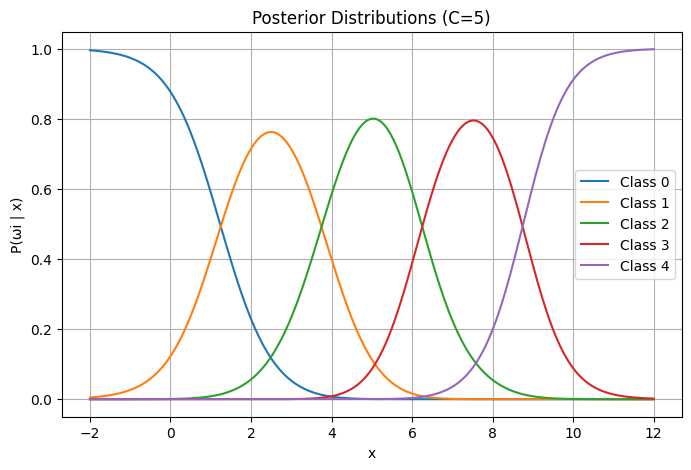

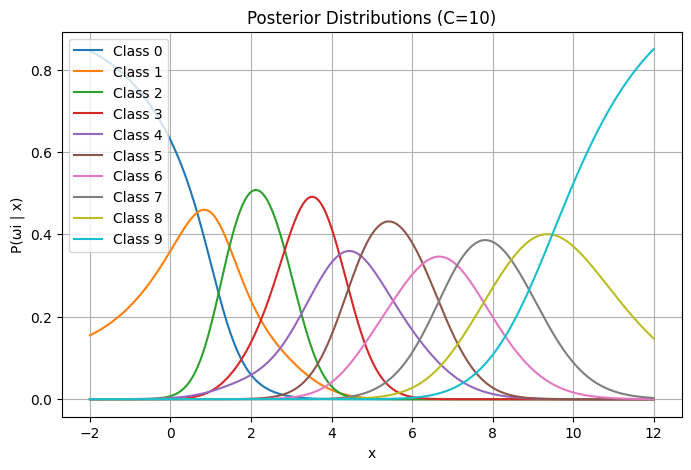

In [1]:
##imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

##Generate Class Parameters
def generate_classes(C):
    means = np.linspace(0, 10, C)
    variances = np.random.uniform(0.5, 2, C)
    priors = np.ones(C) / C  # uniform priors
    return means, variances, priors

##Posterior Computation
def compute_posterior(x, means, variances, priors):
    C = len(means)
    likelihoods = np.zeros(C)

    for i in range(C):
        likelihoods[i] = norm.pdf(x, means[i], np.sqrt(variances[i]))

    numerator = likelihoods * priors
    posterior = numerator / np.sum(numerator)

    return posterior

##Plot Posterior Distributions (C = 5, 10)
def plot_posteriors(C):
    means, variances, priors = generate_classes(C)
    x_vals = np.linspace(-2, 12, 400)

    posteriors = np.zeros((C, len(x_vals)))

    for idx, x in enumerate(x_vals):
        posteriors[:, idx] = compute_posterior(x, means, variances, priors)

    plt.figure(figsize=(8, 5))
    for i in range(C):
        plt.plot(x_vals, posteriors[i], label=f'Class {i}')

    plt.title(f'Posterior Distributions (C={C})')
    plt.xlabel('x')
    plt.ylabel('P(ωi | x)')
    plt.legend()
    plt.grid()
    plt.show()


plot_posteriors(5)
plot_posteriors(10)


In [3]:
##Bayes Decision Rule

def bayes_classifier(x, means, variances, priors):
    posterior = compute_posterior(x, means, variances, priors)
    return np.argmax(posterior)


##Probability of Error Estimation
def estimate_error(C, n_samples=10000):
    means, variances, priors = generate_classes(C)
    errors = 0

    for _ in range(n_samples):
        true_class = np.random.choice(C, p=priors)
        x = np.random.normal(means[true_class], np.sqrt(variances[true_class]))
        predicted = bayes_classifier(x, means, variances, priors)
        if predicted != true_class:
            errors += 1

    return errors / n_samples


for C in [5, 10, 100, 500, 1000]:
    print(f"C={C}, Probability of Error ≈ {estimate_error(C):.4f}")


C=5, Probability of Error ≈ 0.1780
C=10, Probability of Error ≈ 0.5469
C=100, Probability of Error ≈ 0.9454
C=500, Probability of Error ≈ 0.9868
C=1000, Probability of Error ≈ 0.9933


###Computational Complexity:
In multiclass Bayesian classification, the computation of posterior probability for a given input sample requires evaluating the class-conditional likelihood and prior probability for each of the
C classes. Since these calculations are performed independently for every class and then normalized using a summation over all classes, the time complexity of posterior computation is
O(C). Similarly, the Bayes decision rule involves comparing the posterior probabilities of all
C classes to find the maximum, which also requires
O(C) time. Therefore, as the number of classes increases, the overall computational cost grows linearly with
C, making the classifier more computationally expensive for large numbers of classes.

###Question 2: Multiclass Minimum Error Rate Classifier

Discriminant rule: 2
Posterior rule: 2
C=5, Error Rate ≈ 0.2198
C=10, Error Rate ≈ 0.5828
C=50, Error Rate ≈ 0.8872
C=100, Error Rate ≈ 0.9425
C=500, Error Rate ≈ 0.9879


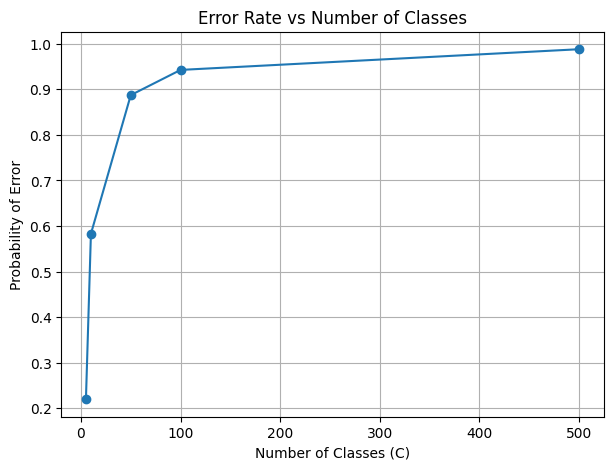

In [8]:
def generate_classes(C):
    means = np.linspace(0, 10, C)
    variances = np.random.uniform(0.5, 2, C)
    priors = np.ones(C) / C
    return means, variances, priors


#Discriminant Function
def discriminant_function(x, means, variances, priors):
    C = len(means)
    g = np.zeros(C)

    for i in range(C):
        log_likelihood = np.log(norm.pdf(x, means[i], np.sqrt(variances[i])))
        log_prior = np.log(priors[i])
        g[i] = log_likelihood + log_prior

    return g


#Minimum Error Rate Classifier
def minimum_error_classifier(x, means, variances, priors):
    g = discriminant_function(x, means, variances, priors)
    return np.argmax(g)


#Verify Equivalence with Posterior Rule
def posterior_classifier(x, means, variances, priors):
    likelihoods = np.array([
        norm.pdf(x, means[i], np.sqrt(variances[i])) for i in range(len(means))
    ])
    posteriors = likelihoods * priors
    posteriors /= np.sum(posteriors)
    return np.argmax(posteriors)

means, variances, priors = generate_classes(5)
x_test = 5.0

print("Discriminant rule:", minimum_error_classifier(x_test, means, variances, priors))
print("Posterior rule:", posterior_classifier(x_test, means, variances, priors))


#Monte Carlo Simulation
def monte_carlo_error(C, samples=10000):
    means, variances, priors = generate_classes(C)
    errors = 0

    for _ in range(samples):
        true_class = np.random.choice(C, p=priors)
        x = np.random.normal(means[true_class], np.sqrt(variances[true_class]))
        predicted = minimum_error_classifier(x, means, variances, priors)
        if predicted != true_class:
            errors += 1

    return errors / samples


#Error Rate vs Number of Classes
C_values = [5, 10, 50, 100, 500]
error_rates = []

for C in C_values:
    error = monte_carlo_error(C)
    error_rates.append(error)
    print(f"C={C}, Error Rate ≈ {error:.4f}")


#Plot Error Rate vs C
plt.figure(figsize=(7,5))
plt.plot(C_values, error_rates, marker='o')
plt.xlabel("Number of Classes (C)")
plt.ylabel("Probability of Error")
plt.title("Error Rate vs Number of Classes")
plt.grid()
plt.show()


Why Error Increases with C

With increasing number of classes, decision boundaries become denser and class distributions overlap more significantly. This reduces separability and increases the probability of classification error.

###Question 3: Multivariate Discriminant Functions

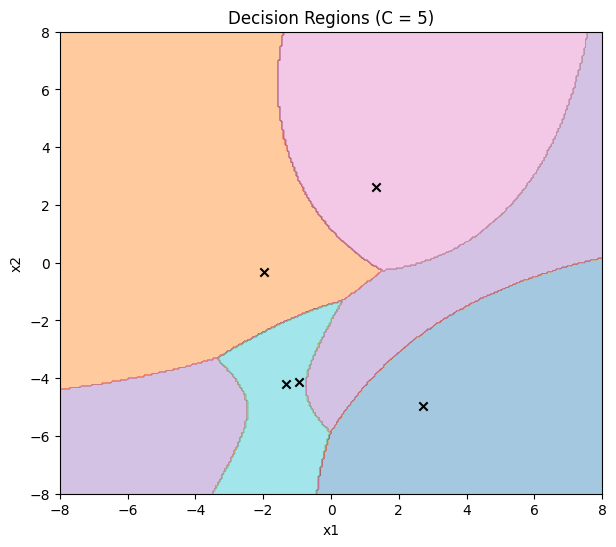

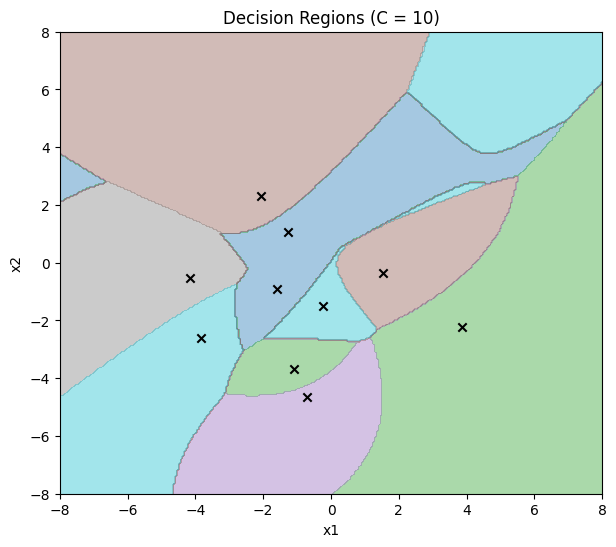

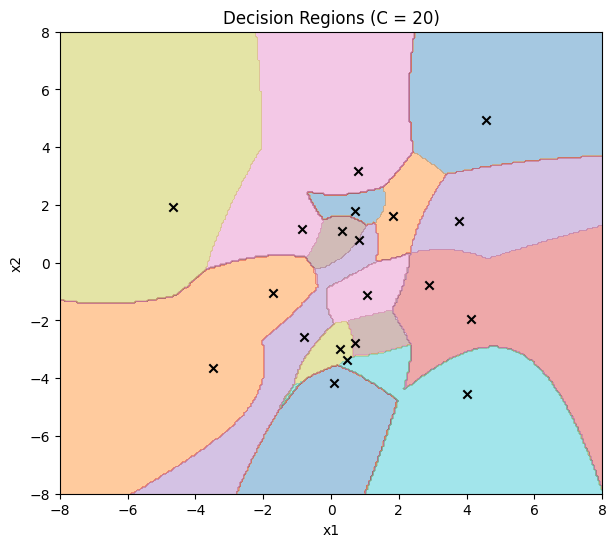

In [9]:
def generate_classes(C):
    means = np.random.uniform(-5, 5, (C, 2))
    covariances = []

    for _ in range(C):
        A = np.random.rand(2, 2)
        cov = A @ A.T + 0.5 * np.eye(2)  # positive definite
        covariances.append(cov)

    priors = np.ones(C) / C
    return means, covariances, priors


def discriminant_function(x, mu, Sigma, prior):
    inv_Sigma = np.linalg.inv(Sigma)
    det_Sigma = np.linalg.det(Sigma)

    term1 = -0.5 * (x - mu).T @ inv_Sigma @ (x - mu)
    term2 = -0.5 * np.log(det_Sigma)
    term3 = np.log(prior)

    return term1 + term2 + term3

def classify(x, means, covariances, priors):
    scores = []
    for i in range(len(means)):
        g = discriminant_function(x, means[i], covariances[i], priors[i])
        scores.append(g)
    return np.argmax(scores)


def plot_decision_regions(C):
    means, covariances, priors = generate_classes(C)

    x1 = np.linspace(-8, 8, 300)
    x2 = np.linspace(-8, 8, 300)
    xx, yy = np.meshgrid(x1, x2)

    grid = np.c_[xx.ravel(), yy.ravel()]
    labels = np.array([classify(p, means, covariances, priors) for p in grid])
    labels = labels.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, labels, alpha=0.4, cmap='tab10')
    plt.scatter(means[:,0], means[:,1], c='black', marker='x')
    plt.title(f'Decision Regions (C = {C})')
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


for C in [5, 10, 20]:
    plot_decision_regions(C)


In [6]:
def compute_accuracy(C, samples=5000):
    means, covariances, priors = generate_classes(C)
    correct = 0

    for _ in range(samples):
        true_class = np.random.choice(C, p=priors)
        x = np.random.multivariate_normal(means[true_class], covariances[true_class])
        pred = classify(x, means, covariances, priors)
        if pred == true_class:
            correct += 1

    return correct / samples

for C in [5, 10, 20, 50]:
    print(f"C={C}, Accuracy ≈ {compute_accuracy(C):.3f}")


C=5, Accuracy ≈ 0.923
C=10, Accuracy ≈ 0.708
C=20, Accuracy ≈ 0.576
C=50, Accuracy ≈ 0.331


Numerical Stability for Large C

For large number of classes, repeated matrix inversions and determinant calculations can lead to numerical instability. Small covariance determinants and ill-conditioned matrices may cause floating-point errors, which can be mitigated using regularization and logarithmic computations.

###Question 4: Linear vs Quadratic Decision Surfaces

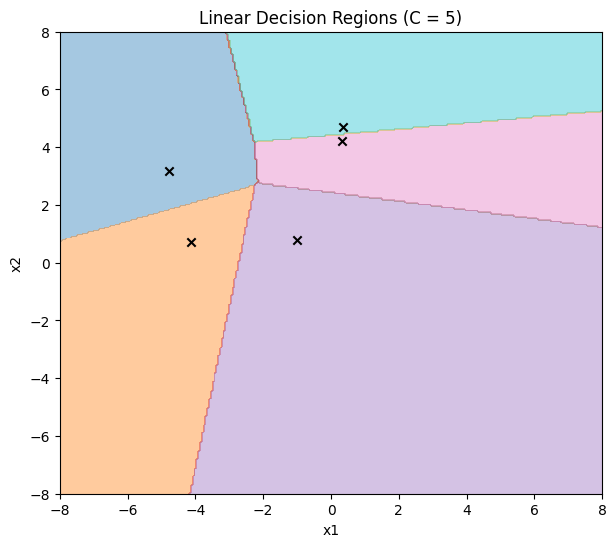

In [7]:
def generate_classes_linear(C):
    means = np.random.uniform(-5, 5, (C, 2))
    Sigma = np.array([[2, 0.3],
                      [0.3, 1.5]])  # common covariance
    priors = np.ones(C) / C
    return means, Sigma, priors


def linear_discriminant(x, mu, Sigma, prior):
    w = np.linalg.inv(Sigma) @ mu
    w0 = -0.5 * mu.T @ np.linalg.inv(Sigma) @ mu + np.log(prior)
    return w.T @ x + w0


def classify_linear(x, means, Sigma, priors):
    scores = []
    for i in range(len(means)):
        g = linear_discriminant(x, means[i], Sigma, priors[i])
        scores.append(g)
    return np.argmax(scores)


def plot_linear_regions(C):
    means, Sigma, priors = generate_classes_linear(C)

    x1 = np.linspace(-8, 8, 300)
    x2 = np.linspace(-8, 8, 300)
    xx, yy = np.meshgrid(x1, x2)
    grid = np.c_[xx.ravel(), yy.ravel()]

    labels = np.array([classify_linear(p, means, Sigma, priors) for p in grid])
    labels = labels.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, labels, alpha=0.4, cmap='tab10')
    plt.scatter(means[:,0], means[:,1], c='black', marker='x')
    plt.title("Linear Decision Regions (C = 5)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


plot_linear_regions(5)

Comparison between Linear and Quadratic Decision Cases:

In the quadratic case, each class has a different covariance matrix, which introduces quadratic terms in the discriminant function and results in curved or nonlinear decision boundaries. This allows better modeling of complex class distributions but increases computational cost and numerical instability. In contrast, the linear case assumes a common covariance matrix for all classes, causing the quadratic terms to cancel out. As a result, the decision boundaries become linear. Linear classifiers are computationally simpler, more stable, and scale better with an increasing number of classes.

Computational Complexity

Linear classifiers require fewer computations as matrix inversion is performed only once, making them more efficient for large numbers of classes.

Why Surfaces Remain Linear Regardless of C

The linearity of decision surfaces depends on the equality of covariance matrices, not on the number of classes. Increasing the number of classes only adds more linear boundaries but does not change their linear nature.

###Question 5: Multiclass Bayesian Risk Minimization

In [10]:
def generate_classes(C):
    means = np.linspace(0, 10, C)
    variances = np.random.uniform(0.5, 2, C)
    priors = np.ones(C) / C
    return means, variances, priors

def compute_posterior(x, means, variances, priors):
    likelihoods = np.array([
        norm.pdf(x, means[i], np.sqrt(variances[i])) for i in range(len(means))
    ])
    posteriors = likelihoods * priors
    return posteriors / np.sum(posteriors)

def risk_based_classifier(x, means, variances, priors, loss_matrix):
    posterior = compute_posterior(x, means, variances, priors)
    risks = loss_matrix @ posterior
    return np.argmin(risks), risks


def minimum_error_classifier(x, means, variances, priors):
    posterior = compute_posterior(x, means, variances, priors)
    return np.argmax(posterior)


C = 5
means, variances, priors = generate_classes(C)

# Zero-One Loss
loss_matrix = np.ones((C, C)) - np.eye(C)

x_test = 5.0
print("Risk-based decision:", risk_based_classifier(x_test, means, variances, priors, loss_matrix)[0])
print("Minimum error decision:", minimum_error_classifier(x_test, means, variances, priors))


Risk-based decision: 2
Minimum error decision: 2


In [11]:
##Unequal Misclassification Costs

loss_matrix = np.ones((C, C))
np.fill_diagonal(loss_matrix, 0)
loss_matrix[0, :] = 3   # higher cost for misclassifying class 0


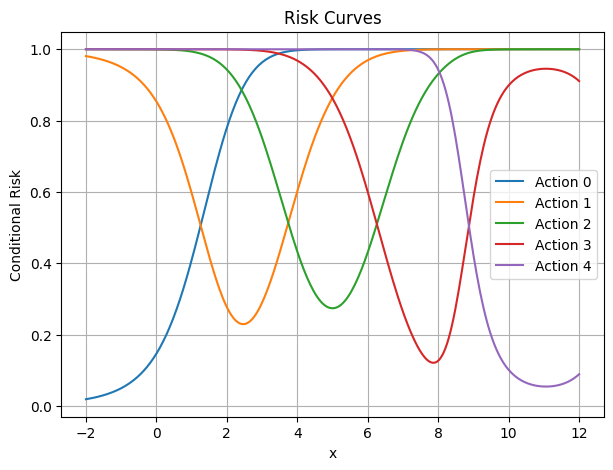

In [12]:
##Plot Risk Curves

def plot_risk_curves(C):
    means, variances, priors = generate_classes(C)
    loss_matrix = np.ones((C, C)) - np.eye(C)
    x_vals = np.linspace(-2, 12, 300)

    risks = np.zeros((C, len(x_vals)))

    for idx, x in enumerate(x_vals):
        posterior = compute_posterior(x, means, variances, priors)
        risks[:, idx] = loss_matrix @ posterior

    plt.figure(figsize=(7,5))
    for i in range(C):
        plt.plot(x_vals, risks[i], label=f'Action {i}')
    plt.xlabel("x")
    plt.ylabel("Conditional Risk")
    plt.title("Risk Curves")
    plt.legend()
    plt.grid()
    plt.show()

plot_risk_curves(5)

Analyze computational burden for C = 1000

For large numbers of classes, Bayesian risk minimization becomes computationally expensive because the risk for each possible action must be computed by summing losses over all classes. This involves matrix–vector multiplication between the loss matrix and posterior probabilities, resulting in
O(C^2
) complexity. As
C increases, both computation time and memory requirements grow rapidly, making the approach less practical for very large multiclass problems.